In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.dirname(c_directory))
sys.path.append(os.path.join(os.path.dirname(c_directory), 'FCYeast'))

import architecture
import FCYeast_simulator
import torch
import eZplot

device='cpu'
l10 = np.log(10)

In [2]:
# Define target
FCYeast_simulator.adjust_device(device)
target = FCYeast_simulator.target()

model = architecture.make_model().to(device)
model.load_state_dict(torch.load('network.pt'))


<All keys matched successfully>

In [3]:
samples,gts =[],[]
for i in (24,48,42):
    g3 = np.loadtxt('FCYeast_MCMC/results_{}data_4096dp.csv'.format(i))#[:,:]

    gt = np.loadtxt('FCYeast_synth/gt_map.csv')
    gt = gt[gt[:,0]==i,1:].reshape(-1)

    samples.append(g3)
    gts.append(gt)

gts


[array([13.04179955, -0.55059999,  0.89450002, -3.44950008]),
 array([13.05150032, -2.0796001 ,  0.66280001, -1.91110003]),
 array([11.01010036, -0.93559998,  1.11720002, -2.12730002])]

In [4]:
def make_mcmc_figure(post_samples,gt):
    fig, ax = plt.subplots(1,4,figsize=(8,2.5))
    make_mcmc_plot(ax.reshape(-1),post_samples,gt)
    fig.tight_layout()
    return fig

def make_mcmc_plot(ax,post_samples,gt,xlabel=True):
    labs = [r'$\beta (\bar{T}^{-1})$',r'$\lambda_{act} (\bar{T}^{-1})$',r'$\lambda_{ina} (\bar{T}^{-1})$',r'$\sigma$']
    first = True
    for post,gti,axi,lab in zip(post_samples.T/l10,gt/l10,ax,labs):
        
        axi.hist(post,density=True)
        if xlabel:
            axi.set_xlabel(r'$\log_{10}$'+(lab),fontsize=14)
        if xlabel and first:
            axi.axvline(gti,color='red',linestyle='dashed',label='Ground Truth')
        else:
            axi.axvline(gti,color='red',linestyle='dashed')

        first=False

    

[13.04179955 -0.55059999  0.89450002 -3.44950008]
[13.05150032 -2.0796001   0.66280001 -1.91110003]
[11.01010036 -0.93559998  1.11720002 -2.12730002]


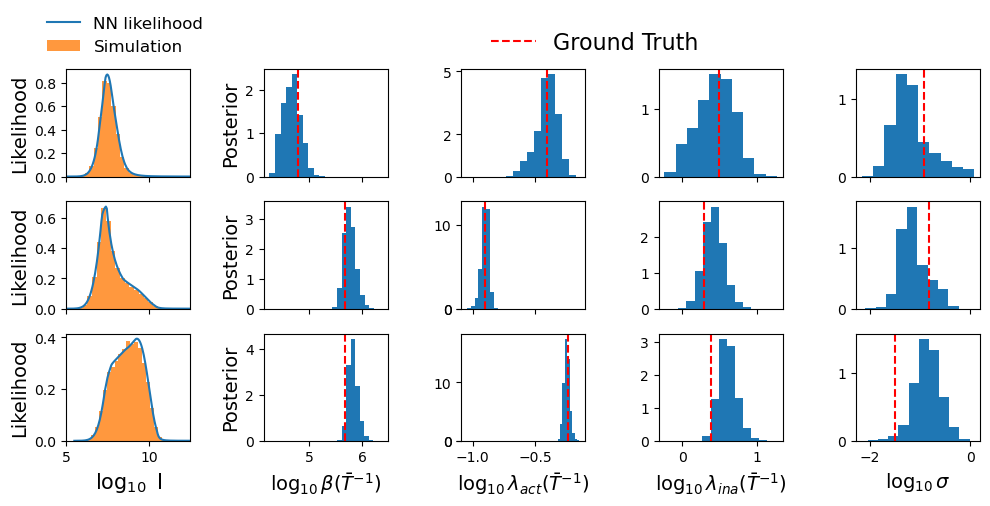

In [5]:
fig, ax = plt.subplots(3,5,figsize=(10,5),sharex='col')


first = True
for axi,thi,sam in zip(reversed(ax),gts,samples):
    print(thi)
    eZplot.make_plot(axi[0],torch.tensor(thi).float(),model,target,legend=first)
    axi[0].set_ylabel(r'Likelihood',fontsize=14)    
    make_mcmc_plot(axi[1:],sam,thi,xlabel=first)
    axi[1].set_ylabel(r'Posterior',fontsize=14) 
    first = False
ax[-1,0].set_xlabel(r'$\log_{10}$ I',fontsize=15)
ax[-1,0].get_legend().remove()

handles1, labels1 = ax[-1, 0].get_legend_handles_labels()
fig.legend(handles1, labels1, loc='upper center', bbox_to_anchor=(0.13, 1.02), ncol=1, frameon=False,fontsize=12)

# Second figure-wide legend: Handles from one of the other subplots
handles2, labels2 = ax[-1, 1].get_legend_handles_labels()
fig.legend(handles2, labels2, loc='upper center', bbox_to_anchor=(0.6, 1.0), ncol=1, frameon=False,fontsize=16)

for axi in ax[:,1:].flatten():
    #axi.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))    
    ymax = axi.get_ylim()[1]
    pow = np.floor(np.log10(ymax))
    ticks = np.arange(0, int(np.ceil(ymax)))
        

    if len(ticks) > 4:
        ticks = np.linspace(0, ticks[-1], 3)
        ticks = (ticks/(10**pow)).astype(int)*(10**pow)

    axi.set_yticks(ticks)
for axi in ax[:,0]:
    axi.yaxis.set_major_locator(ticker.MultipleLocator(0.2))

ax[0][0].set_xlim(5,12.5)


fig.tight_layout(rect=[0, 0, 1, 0.92]) 
fig.savefig('panelbc',dpi=500)

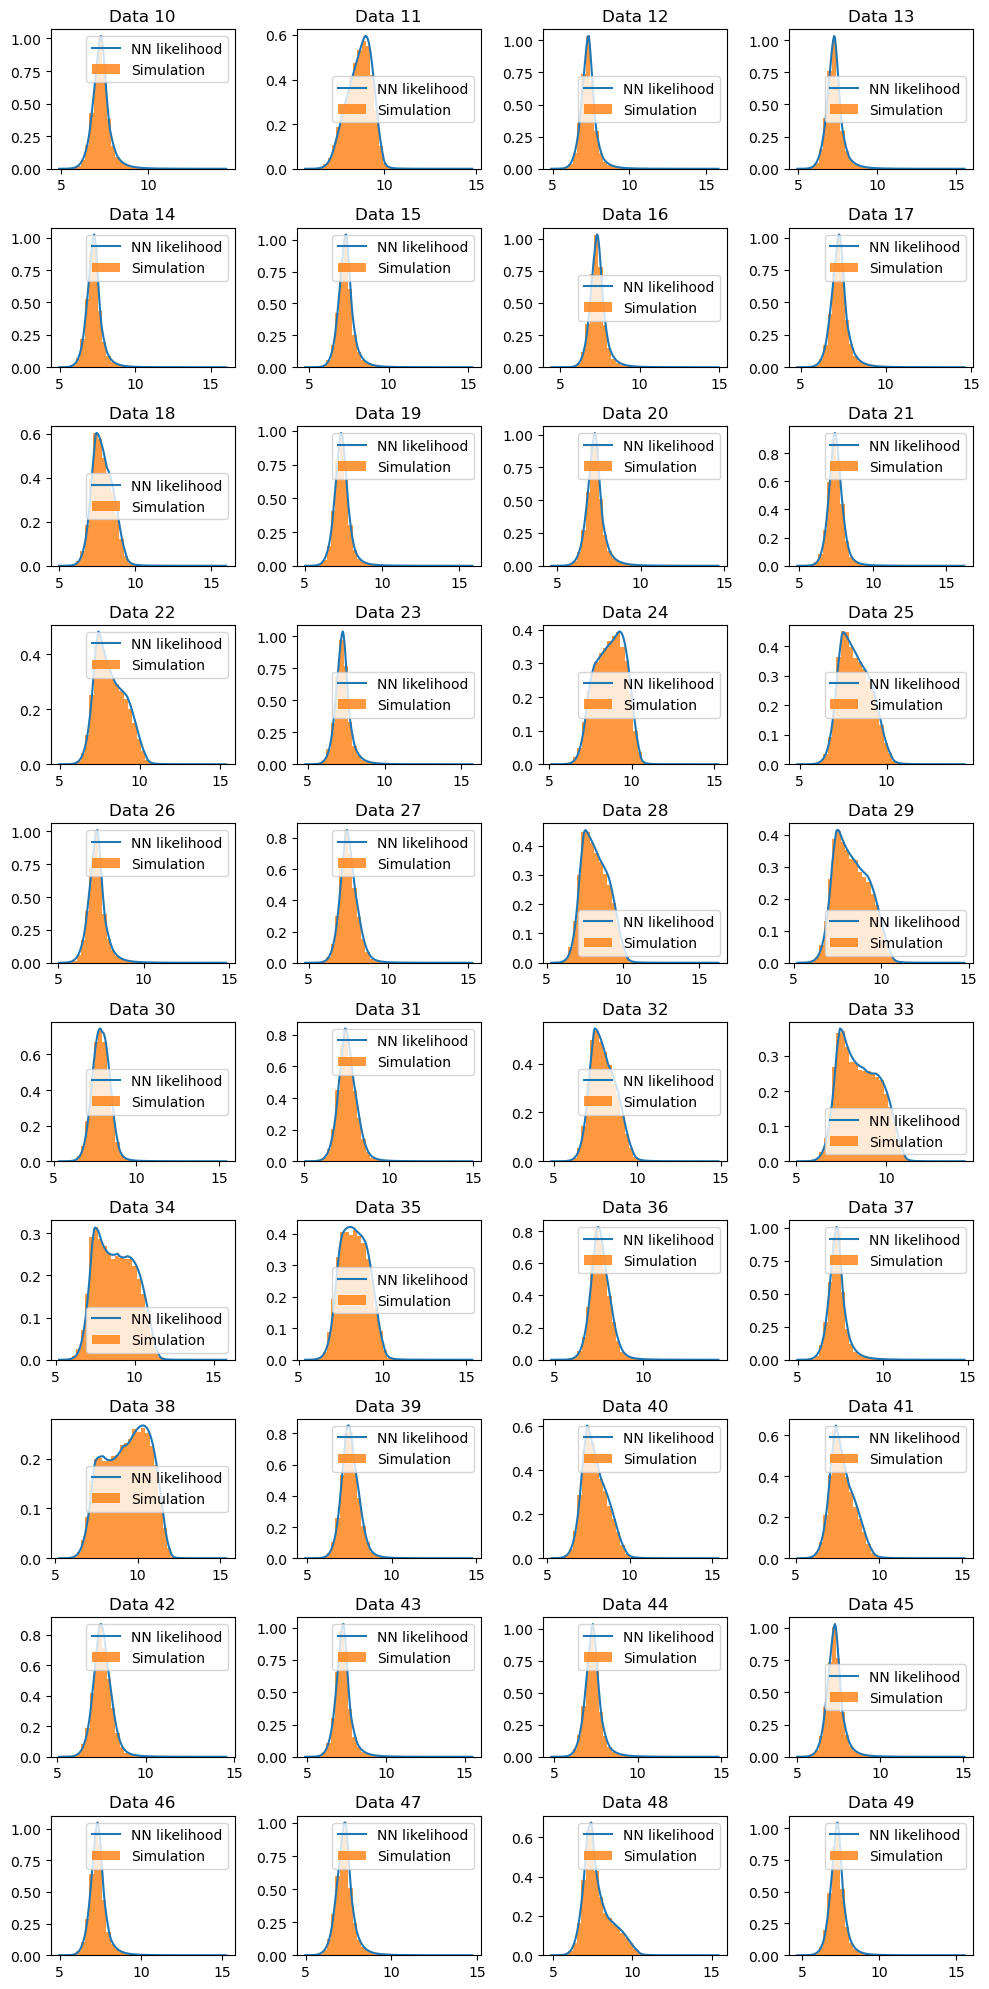

In [6]:
fig, ax = plt.subplots(10,4,figsize=(10,2.*10))


first = True
axflat = ax.reshape(-1)
gt = np.loadtxt('FCYeast_synth/gt_map.csv')
for i in range(40):
    thi = gt[gt[:,0]==i+10,1:].reshape(-1)
    eZplot.make_plot(axflat[i],torch.tensor(thi).float(),model,target,legend=first)
    axflat[i].set_title('Data {}'.format(i+10))
plt.tight_layout()

In [7]:
thi = np.array((11,1,-1,-2))
thi = np.array((13,-1.2, 0.8, -2.5))

[13.  -1.2  0.8 -2.5]
[13.  -0.2  1.8 -2.5]
[13.   0.8  2.8 -2.5]


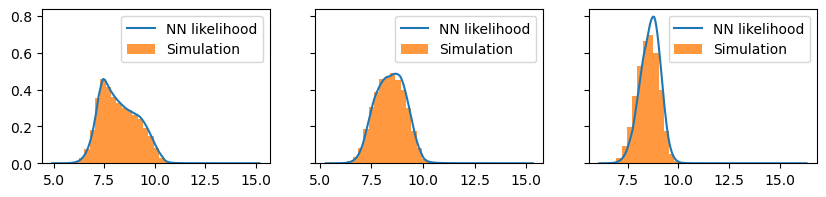

In [8]:
fig, ax = plt.subplots(1,3,figsize=(10,2.),sharey=True)
first = True
for i in range(3):
    th_new = thi +((0,i,i,0))
    print(th_new)
    eZplot.make_plot(ax[i],torch.tensor(th_new).float(),model,target,legend=first)
    # axi[0].set_ylabel(r'Likelihood',fontsize=14)    
    # make_mcmc_plot(axi[1:],sam,thi,xlabel=first)
    # axi[1].set_ylabel(r'Posterior',fontsize=14) 